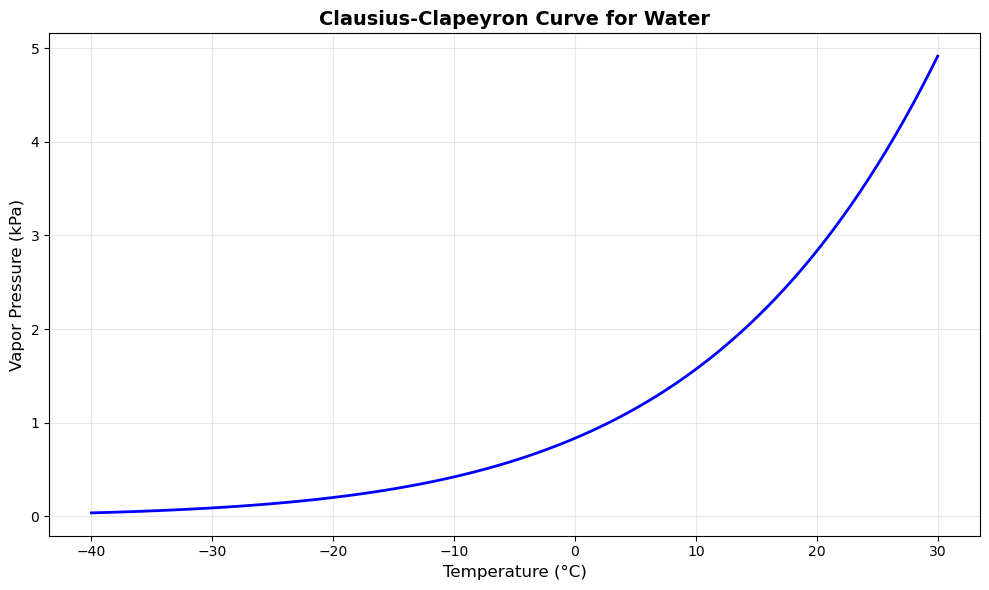

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
R = 8.314  # Universal gas constant (J/(mol·K))
L = 40660  # Latent heat of vaporization for water (J/mol)
P0 = 101325  # Reference pressure at 100°C (Pa)
T0 = 373.15  # Reference temperature (K)

# Temperature range (convert from Celsius to Kelvin)
T_celsius = np.linspace(-40, 30, 100)
T_kelvin = T_celsius + 273.15

# Clausius-Clapeyron equation: ln(P/P0) = -(L/R) * (1/T - 1/T0)
# Solving for P: P = P0 * exp(-(L/R) * (1/T - 1/T0))
P = P0 * np.exp(-(L/R) * (1/T_kelvin - 1/T0))

# Convert pressure to kPa for easier reading
P_kPa = P / 1000

# Create the plot
plt.figure(figsize=(10, 6))
plt.plot(T_celsius, P_kPa, 'b-', linewidth=2)
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Vapor Pressure (kPa)', fontsize=12)
plt.title('Clausius-Clapeyron Curve for Water', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

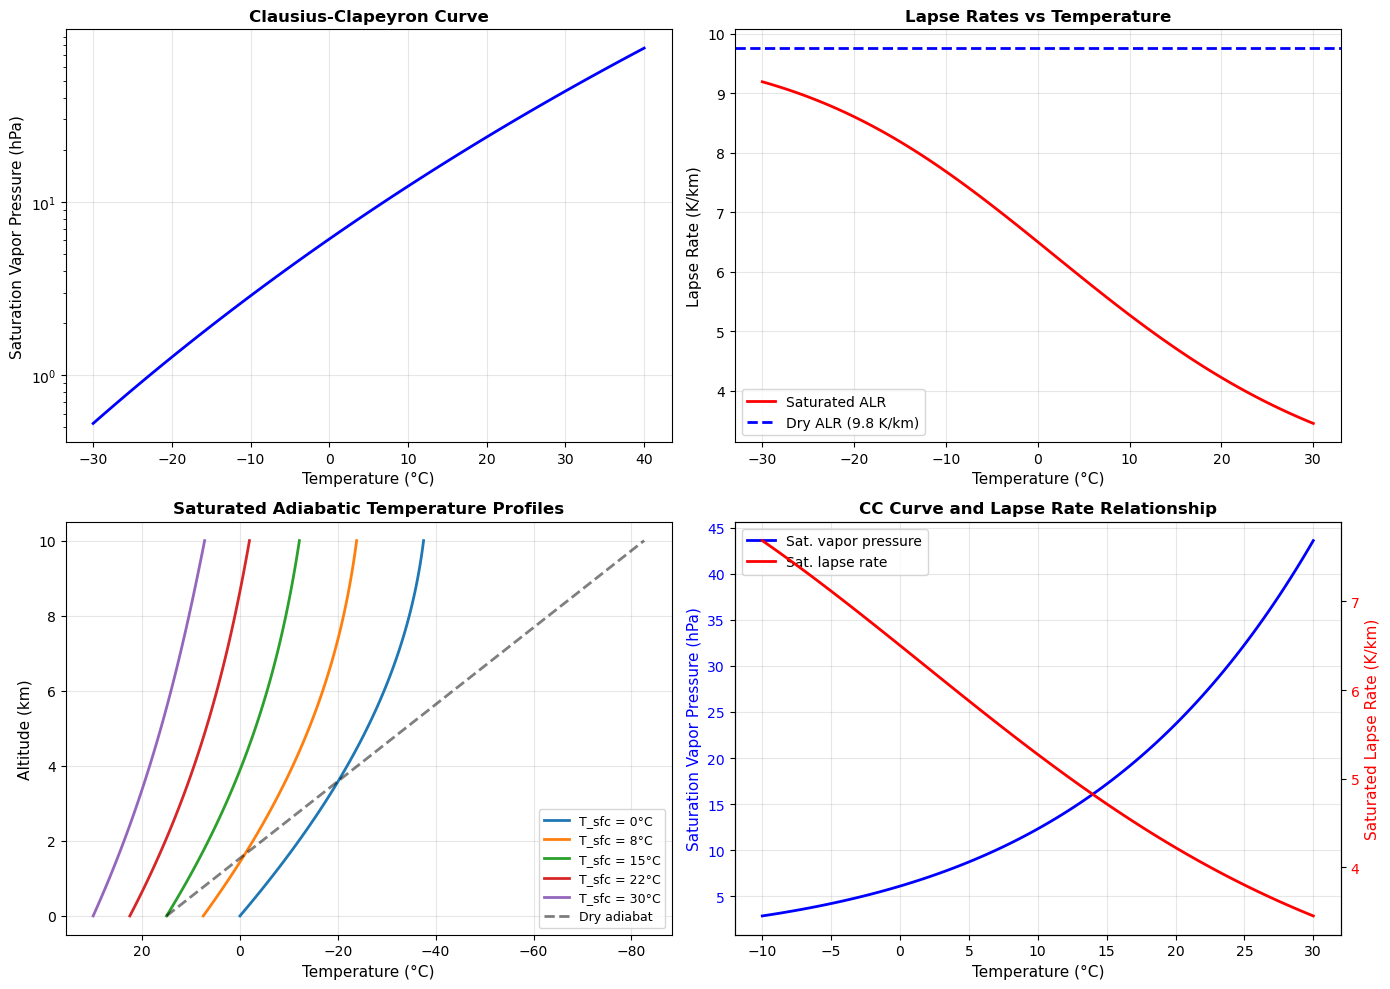

Dry Adiabatic Lapse Rate: 9.76 K/km
Saturated ALR at 20°C: 4.22 K/km
Saturated ALR at 0°C: 6.50 K/km


In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
R = 8.314  # Universal gas constant (J/(mol·K))
Rd = 287  # Specific gas constant for dry air (J/(kg·K))
Rv = 461  # Specific gas constant for water vapor (J/(kg·K))
cp = 1005  # Specific heat of air at constant pressure (J/(kg·K))
g = 9.81  # Gravitational acceleration (m/s²)
L = 2.5e6  # Latent heat of vaporization for water (J/kg)
P0 = 101325  # Reference pressure at sea level (Pa)
T0 = 288.15  # Reference temperature at sea level (K, 15°C)

# Dry adiabatic lapse rate (constant)
DALR = g / cp  # approximately 9.8 K/km

def saturation_vapor_pressure(T):
    """Calculate saturation vapor pressure using Clausius-Clapeyron"""
    # Using simplified form with reference at 273.15 K
    T_ref = 273.15
    es_ref = 611  # Pa at 0°C
    return es_ref * np.exp((L/Rv) * (1/T_ref - 1/T))

def saturated_adiabatic_lapse_rate(T, P):
    """Calculate the saturated (moist) adiabatic lapse rate"""
    es = saturation_vapor_pressure(T)
    ws = 0.622 * es / (P - es)  # Saturation mixing ratio
    
    numerator = g * (1 + (L * ws) / (Rd * T))
    denominator = cp + (L**2 * ws * 0.622) / (Rd * T**2)
    
    return numerator / denominator

# Temperature and altitude ranges
altitude = np.linspace(0, 10000, 100)  # 0 to 10 km
T_surface = np.linspace(273.15, 303.15, 5)  # Different surface temps: 0°C to 30°C

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Clausius-Clapeyron curve
ax1 = axes[0, 0]
T_range = np.linspace(243.15, 313.15, 100)  # -30°C to 40°C
es = saturation_vapor_pressure(T_range)
ax1.semilogy(T_range - 273.15, es/100, 'b-', linewidth=2)  # Convert to hPa
ax1.set_xlabel('Temperature (°C)', fontsize=11)
ax1.set_ylabel('Saturation Vapor Pressure (hPa)', fontsize=11)
ax1.set_title('Clausius-Clapeyron Curve', fontsize=12, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Plot 2: Lapse rates vs temperature
ax2 = axes[0, 1]
T_range2 = np.linspace(243.15, 303.15, 100)
P_surf = 101325  # Surface pressure
SALR_values = [saturated_adiabatic_lapse_rate(T, P_surf) * 1000 for T in T_range2]
ax2.plot(T_range2 - 273.15, SALR_values, 'r-', linewidth=2, label='Saturated ALR')
ax2.axhline(y=DALR*1000, color='b', linestyle='--', linewidth=2, label=f'Dry ALR ({DALR*1000:.1f} K/km)')
ax2.set_xlabel('Temperature (°C)', fontsize=11)
ax2.set_ylabel('Lapse Rate (K/km)', fontsize=11)
ax2.set_title('Lapse Rates vs Temperature', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Temperature profiles for different surface conditions
ax3 = axes[1, 0]
for T_surf in T_surface:
    T_profile = []
    for z in altitude:
        P = P0 * (1 - (g * z) / (cp * T0))**(cp/Rd)  # Approximate pressure
        gamma = saturated_adiabatic_lapse_rate(T_surf, P)
        T_at_z = T_surf - gamma * z
        T_profile.append(T_at_z - 273.15)
    
    ax3.plot(T_profile, altitude/1000, linewidth=2, 
             label=f'T_sfc = {T_surf-273.15:.0f}°C')

# Add dry adiabat for comparison
T_dry = T_surface[2] - DALR * altitude
ax3.plot(T_dry - 273.15, altitude/1000, 'k--', linewidth=2, 
         label='Dry adiabat', alpha=0.5)

ax3.set_xlabel('Temperature (°C)', fontsize=11)
ax3.set_ylabel('Altitude (km)', fontsize=11)
ax3.set_title('Saturated Adiabatic Temperature Profiles', fontsize=12, fontweight='bold')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.invert_xaxis()

# Plot 4: Relationship between CC and lapse rate
ax4 = axes[1, 1]
T_range3 = np.linspace(263.15, 303.15, 100)
es_vals = saturation_vapor_pressure(T_range3)
SALR_vals = [saturated_adiabatic_lapse_rate(T, P_surf) * 1000 for T in T_range3]

# Normalize both to 0-1 for comparison
es_norm = (es_vals - es_vals.min()) / (es_vals.max() - es_vals.min())
SALR_norm = (SALR_vals - np.min(SALR_vals)) / (np.max(SALR_vals) - np.min(SALR_vals))

ax4_twin = ax4.twinx()
line1 = ax4.plot(T_range3 - 273.15, es_vals/100, 'b-', linewidth=2, label='Sat. vapor pressure')
line2 = ax4_twin.plot(T_range3 - 273.15, SALR_vals, 'r-', linewidth=2, label='Sat. lapse rate')

ax4.set_xlabel('Temperature (°C)', fontsize=11)
ax4.set_ylabel('Saturation Vapor Pressure (hPa)', fontsize=11, color='b')
ax4_twin.set_ylabel('Saturated Lapse Rate (K/km)', fontsize=11, color='r')
ax4.set_title('CC Curve and Lapse Rate Relationship', fontsize=12, fontweight='bold')
ax4.tick_params(axis='y', labelcolor='b')
ax4_twin.tick_params(axis='y', labelcolor='r')

# Combine legends
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax4.legend(lines, labels, loc='upper left')
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Dry Adiabatic Lapse Rate: {DALR*1000:.2f} K/km")
print(f"Saturated ALR at 20°C: {saturated_adiabatic_lapse_rate(293.15, P0)*1000:.2f} K/km")
print(f"Saturated ALR at 0°C: {saturated_adiabatic_lapse_rate(273.15, P0)*1000:.2f} K/km")

/var/folders/bb/wssqxcxj4tgg0s9fdw74731m0000gn/T/ipykernel_1443/1149342173.py:66: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "g-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(T_range - 273.15, lapse_saturated, 'g-', linewidth=3,


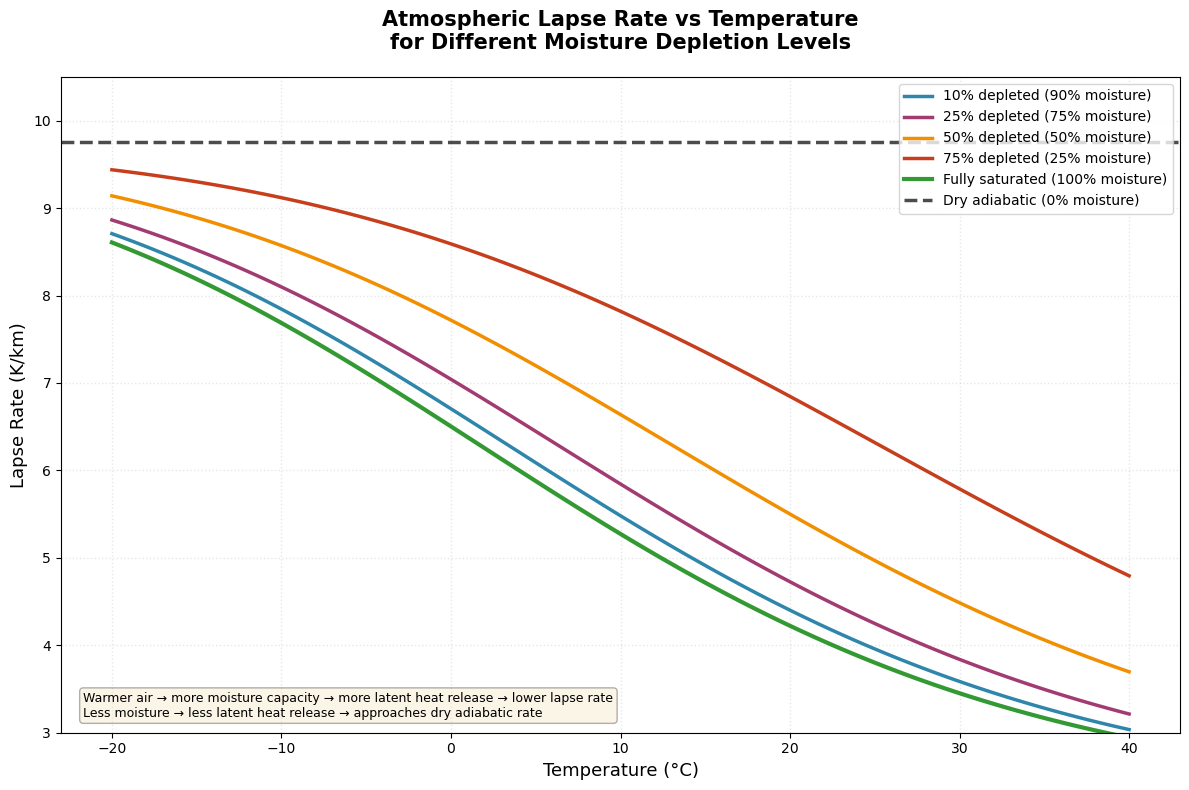


Lapse rates at 20°C (293.15 K):
Dry adiabatic: 9.76 K/km
10% depleted (90% moisture): 4.40 K/km
25% depleted (75% moisture): 4.73 K/km
50% depleted (50% moisture): 5.50 K/km
75% depleted (25% moisture): 6.85 K/km
Fully saturated: 4.22 K/km


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
Rd = 287  # Specific gas constant for dry air (J/(kg·K))
Rv = 461  # Specific gas constant for water vapor (J/(kg·K))
cp = 1005  # Specific heat of air at constant pressure (J/(kg·K))
g = 9.81  # Gravitational acceleration (m/s²)
L = 2.5e6  # Latent heat of vaporization for water (J/kg)
P0 = 101325  # Reference pressure at sea level (Pa)

# Dry adiabatic lapse rate (constant)
DALR = g / cp  # approximately 9.8 K/km

def saturation_vapor_pressure(T):
    """Calculate saturation vapor pressure using Clausius-Clapeyron"""
    T_ref = 273.15
    es_ref = 611  # Pa at 0°C
    return es_ref * np.exp((L/Rv) * (1/T_ref - 1/T))

def lapse_rate_with_depletion(T, P, moisture_fraction):
    """
    Calculate lapse rate when air has been depleted of moisture
    moisture_fraction: fraction of saturation moisture remaining (0 to 1)
    """
    es = saturation_vapor_pressure(T)
    ws_sat = 0.622 * es / (P - es)  # Saturation mixing ratio
    ws = ws_sat * moisture_fraction  # Actual mixing ratio after depletion
    
    # If no moisture, return dry adiabatic lapse rate
    if ws <= 0:
        return DALR
    
    numerator = g * (1 + (L * ws) / (Rd * T))
    denominator = cp + (L**2 * ws * 0.622) / (Rd * T**2)
    
    return numerator / denominator

# Temperature range
T_range = np.linspace(253.15, 313.15, 100)  # -20°C to 40°C
P_surf = 101325  # Surface pressure

# Moisture depletion scenarios
depletion_scenarios = [
    (0.90, '10% depleted (90% moisture)'),
    (0.75, '25% depleted (75% moisture)'),
    (0.50, '50% depleted (50% moisture)'),
    (0.25, '75% depleted (25% moisture)')
]

# Create the plot
plt.figure(figsize=(12, 8))

# Plot each depletion scenario
colors = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D']
for (moisture_frac, label), color in zip(depletion_scenarios, colors):
    lapse_rates = [lapse_rate_with_depletion(T, P_surf, moisture_frac) * 1000 
                   for T in T_range]
    plt.plot(T_range - 273.15, lapse_rates, linewidth=2.5, 
             label=label, color=color)

# Add reference lines
# Fully saturated (100% moisture)
lapse_saturated = [lapse_rate_with_depletion(T, P_surf, 1.0) * 1000 
                   for T in T_range]
plt.plot(T_range - 273.15, lapse_saturated, 'g-', linewidth=3, 
         label='Fully saturated (100% moisture)', linestyle='-', alpha=0.8)

# Dry adiabatic lapse rate (0% moisture)
plt.axhline(y=DALR*1000, color='k', linestyle='--', linewidth=2.5, 
            label=f'Dry adiabatic (0% moisture)', alpha=0.7)

plt.xlabel('Temperature (°C)', fontsize=13)
plt.ylabel('Lapse Rate (K/km)', fontsize=13)
plt.title('Atmospheric Lapse Rate vs Temperature\nfor Different Moisture Depletion Levels', 
          fontsize=15, fontweight='bold', pad=20)
plt.legend(fontsize=10, loc='upper right')
plt.grid(True, alpha=0.3, linestyle=':', linewidth=1)
plt.ylim([3, 10.5])

# Add annotation explaining the physics
textstr = ('Warmer air → more moisture capacity → more latent heat release → lower lapse rate\n'
           'Less moisture → less latent heat release → approaches dry adiabatic rate')
plt.text(0.02, 0.02, textstr, transform=plt.gca().transAxes, 
         fontsize=9, verticalalignment='bottom',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

# Print some key values
print("\nLapse rates at 20°C (293.15 K):")
print(f"Dry adiabatic: {DALR*1000:.2f} K/km")
for moisture_frac, label in depletion_scenarios:
    lr = lapse_rate_with_depletion(293.15, P_surf, moisture_frac) * 1000
    print(f"{label}: {lr:.2f} K/km")
lr_sat = lapse_rate_with_depletion(293.15, P_surf, 1.0) * 1000
print(f"Fully saturated: {lr_sat:.2f} K/km")

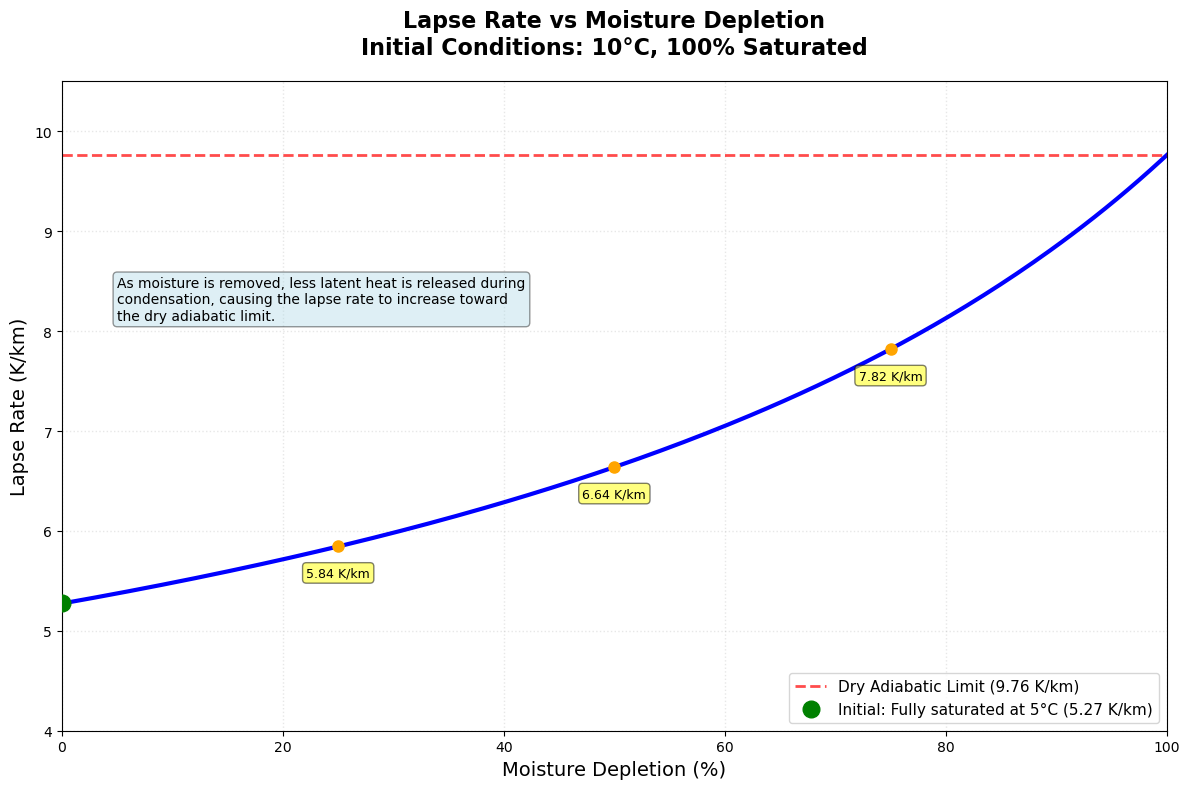


Initial Temperature: 10°C
Initial Saturation: 100%

Lapse Rate Summary:
  0% depletion (100% moisture): 5.274 K/km
 25% depletion ( 75% moisture): 5.844 K/km
 50% depletion ( 50% moisture): 6.639 K/km
 75% depletion ( 25% moisture): 7.820 K/km
 100% depletion (  0% moisture): 9.761 K/km


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
Rd = 287  # Specific gas constant for dry air (J/(kg·K))
Rv = 461  # Specific gas constant for water vapor (J/(kg·K))
cp = 1005  # Specific heat of air at constant pressure (J/(kg·K))
g = 9.81  # Gravitational acceleration (m/s²)
L = 2.5e6  # Latent heat of vaporization for water (J/kg)
P0 = 101325  # Reference pressure at sea level (Pa)

# Dry adiabatic lapse rate (constant)
DALR = g / cp  # approximately 9.8 K/km

def saturation_vapor_pressure(T):
    """Calculate saturation vapor pressure using Clausius-Clapeyron"""
    T_ref = 273.15
    es_ref = 611  # Pa at 0°C
    return es_ref * np.exp((L/Rv) * (1/T_ref - 1/T))

def lapse_rate_with_depletion(T, P, moisture_fraction):
    """
    Calculate lapse rate when air has been depleted of moisture
    moisture_fraction: fraction of saturation moisture remaining (0 to 1)
    """
    es = saturation_vapor_pressure(T)
    ws_sat = 0.622 * es / (P - es)  # Saturation mixing ratio
    ws = ws_sat * moisture_fraction  # Actual mixing ratio after depletion
    
    # If no moisture, return dry adiabatic lapse rate
    if ws <= 0:
        return DALR
    
    numerator = g * (1 + (L * ws) / (Rd * T))
    denominator = cp + (L**2 * ws * 0.622) / (Rd * T**2)
    
    return numerator / denominator

# Initial conditions
T_initial = 10.0 + 273.15  # 5°C in Kelvin
P_surf = 101325  # Surface pressure
initial_saturation = 1.0  # 100% saturated

# Moisture depletion range (0% to 100% depletion)
# 0% depletion = 100% moisture remaining
# 100% depletion = 0% moisture remaining
depletion_percent = np.linspace(0, 100, 200)
moisture_remaining = 1.0 - (depletion_percent / 100)

# Calculate lapse rate for each depletion level
lapse_rates = [lapse_rate_with_depletion(T_initial, P_surf, moist_frac) * 1000 
               for moist_frac in moisture_remaining]

# Create the plot
plt.figure(figsize=(12, 8))
plt.plot(depletion_percent, lapse_rates, 'b-', linewidth=3)

# Add reference lines
plt.axhline(y=DALR*1000, color='red', linestyle='--', linewidth=2, 
            label=f'Dry Adiabatic Limit ({DALR*1000:.2f} K/km)', alpha=0.7)

# Mark the initial saturated point
initial_lapse_rate = lapse_rate_with_depletion(T_initial, P_surf, 1.0) * 1000
plt.plot(0, initial_lapse_rate, 'go', markersize=12, 
         label=f'Initial: Fully saturated at 5°C ({initial_lapse_rate:.2f} K/km)', 
         zorder=5)

# Mark some key points
for depl in [25, 50, 75]:
    moist = 1.0 - (depl / 100)
    lr = lapse_rate_with_depletion(T_initial, P_surf, moist) * 1000
    plt.plot(depl, lr, 'o', markersize=8, color='orange', zorder=5)
    plt.text(depl, lr - 0.3, f'{lr:.2f} K/km', ha='center', fontsize=9,
             bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))

plt.xlabel('Moisture Depletion (%)', fontsize=14)
plt.ylabel('Lapse Rate (K/km)', fontsize=14)
plt.title(f'Lapse Rate vs Moisture Depletion\nInitial Conditions: {T_initial-273.15:.0f}°C, 100% Saturated', 
          fontsize=16, fontweight='bold', pad=20)
plt.legend(fontsize=11, loc='lower right')
plt.grid(True, alpha=0.3, linestyle=':', linewidth=1)
plt.xlim([0, 100])
plt.ylim([4, 10.5])

# Add annotation
textstr = ('As moisture is removed, less latent heat is released during\n'
           'condensation, causing the lapse rate to increase toward\n'
           'the dry adiabatic limit.')
plt.text(0.05, 0.7, textstr, transform=plt.gca().transAxes, 
         fontsize=10, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.4))

plt.tight_layout()
plt.show()

# Print summary statistics
print(f"\nInitial Temperature: {T_initial-273.15:.0f}°C")
print(f"Initial Saturation: 100%")
print(f"\nLapse Rate Summary:")
print(f"  0% depletion (100% moisture): {initial_lapse_rate:.3f} K/km")
for depl in [25, 50, 75, 100]:
    moist = 1.0 - (depl / 100)
    lr = lapse_rate_with_depletion(T_initial, P_surf, moist) * 1000
    print(f" {depl:2d}% depletion ({100-depl:3d}% moisture): {lr:.3f} K/km")

Initial conditions:
  Temperature: 5 degree_Celsius
  Pressure: 1000 hectopascal
  Saturation mixing ratio: 0.0055 dimensionless

At 2000 meter:
  Pressure: 794.85 hectopascal
  Temperature after moist ascent: 14.60 degree_Celsius
  Saturation mixing ratio: 0.0133 dimensionless

Water condensed during ascent: -0.0078 dimensionless
  Amount precipitated (50%): -0.0039 dimensionless
  Amount remaining in parcel: 0.0094 dimensionless

Final temperature at sea level: 2.19 degree_Celsius
Temperature change: -2.81 delta_degree_Celsius

Lapse Rates:
  Initial (saturated at 5.0 degree_Celsius): 5.85 kelvin / kilometer
  Final (unsaturated at 2.2 degree_Celsius): 6.20 kelvin / kilometer
  If final were saturated: 6.20 kelvin / kilometer
  Dry adiabatic limit: 9.80 kelvin / kilometer


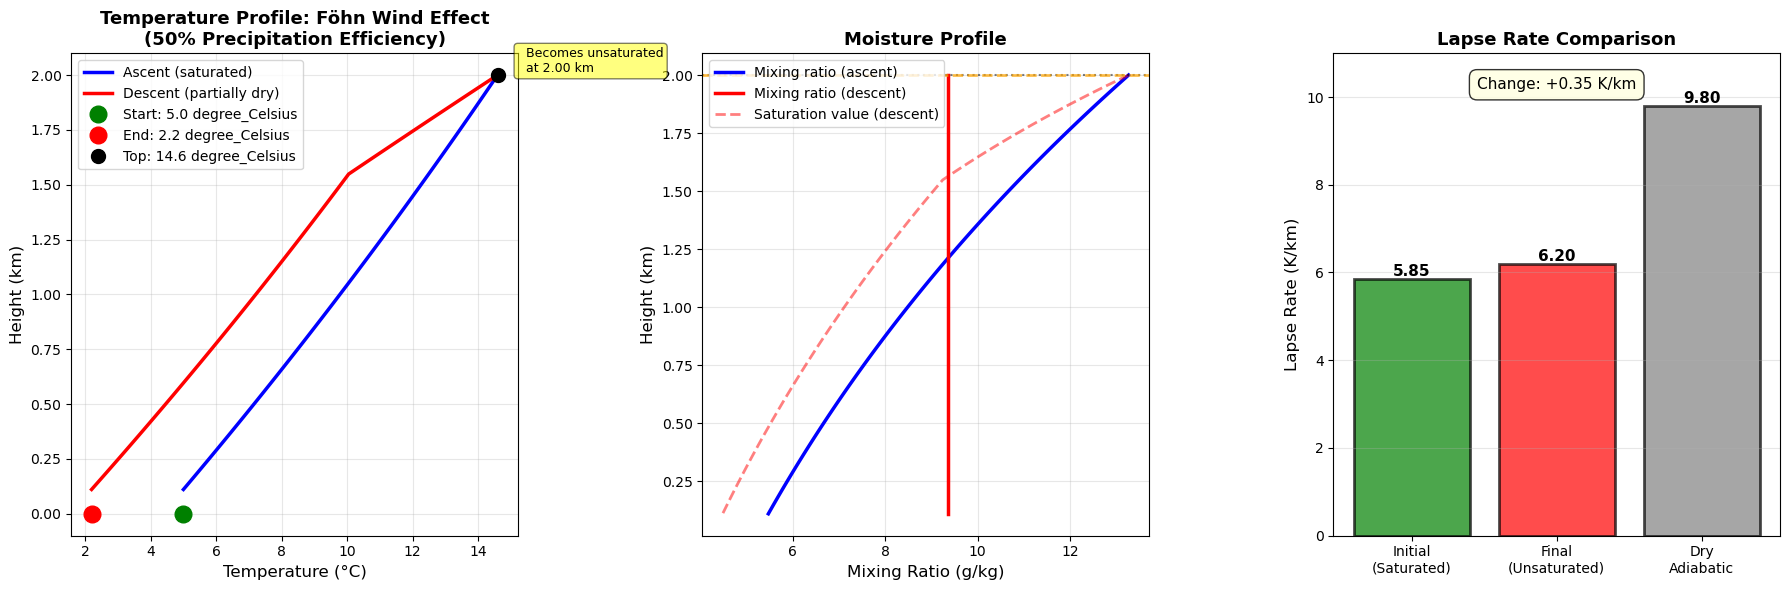


FÖHN WIND SUMMARY
Starting conditions: 5.0 degree_Celsius, 100 percent
Lifted to: 2000 meter
Precipitation efficiency: 50%
Final temperature: 2.2 degree_Celsius
Net warming: -2.81 delta_degree_Celsius
Final moisture: 0.0094 dimensionless (vs initial 0.0055 dimensionless)

Lapse rate increased from 5.85 kelvin / kilometer to 6.20 kelvin / kilometer
Change: +0.35 kelvin / kilometer


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from metpy.units import units
from metpy.calc import (
    saturation_mixing_ratio,
    moist_lapse,
    dry_lapse,
    dewpoint_from_relative_humidity,
    relative_humidity_from_mixing_ratio,
    pressure_to_height_std,
    height_to_pressure_std
)

# Initial conditions at sea level
T_initial = 5 * units.degC
P_initial = 1000 * units.hPa
RH_initial = 100 * units.percent  # Fully saturated

# Target elevation
z_top = 2000 * units.meter

# Precipitation efficiency (50% of condensed water precipitates out)
precip_efficiency = 0.5

# Calculate initial saturation mixing ratio
ws_initial = saturation_mixing_ratio(P_initial, T_initial)

# Calculate pressure at 2000m
P_top = height_to_pressure_std(z_top)

print(f"Initial conditions:")
print(f"  Temperature: {T_initial}")
print(f"  Pressure: {P_initial}")
print(f"  Saturation mixing ratio: {ws_initial:.4f}")
print(f"\nAt {z_top}:")
print(f"  Pressure: {P_top:.2f}")

# ASCENT: Calculate temperature at top using moist adiabatic lapse rate
T_top = moist_lapse(P_initial, T_initial, P_top)
print(f"  Temperature after moist ascent: {T_top:.2f}")

# Calculate saturation mixing ratio at the top
ws_top = saturation_mixing_ratio(P_top, T_top)
print(f"  Saturation mixing ratio: {ws_top:.4f}")

# Calculate how much water condensed during ascent
water_condensed = ws_initial - ws_top
print(f"\nWater condensed during ascent: {water_condensed:.4f}")

# Calculate how much precipitated out vs stayed in parcel
water_precipitated = water_condensed * precip_efficiency
water_remaining = ws_top + water_condensed * (1 - precip_efficiency)
print(f"  Amount precipitated (50%): {water_precipitated:.4f}")
print(f"  Amount remaining in parcel: {water_remaining:.4f}")

# DESCENT: Now descend with reduced moisture
# Create pressure levels for descent
n_levels = 100
P_descent = np.linspace(P_top.magnitude, P_initial.magnitude, n_levels) * units.hPa
T_descent_list = []
T_descent_list.append(T_top)

# Descend level by level
for i in range(1, n_levels):
    # Check if saturated at current level
    ws_sat = saturation_mixing_ratio(P_descent[i-1], T_descent_list[i-1])
    
    if water_remaining >= ws_sat:
        # Still saturated - use moist adiabatic lapse rate
        T_new = moist_lapse(P_descent[i-1], T_descent_list[i-1], P_descent[i])
    else:
        # Unsaturated - use dry adiabatic lapse rate
        T_new = dry_lapse(P_descent[i-1], T_descent_list[i-1], P_descent[i])
    
    T_descent_list.append(T_new)

# Convert to array
T_descent = np.array([t.to(units.degC).magnitude for t in T_descent_list]) * units.degC

T_final = T_descent_list[-1].to(units.degC)  # Fixed: explicitly convert to Celsius
print(f"\nFinal temperature at sea level: {T_final:.2f}")
print(f"Temperature change: {(T_final - T_initial).to(units.delta_degC):.2f}")

# Calculate lapse rates
def calculate_lapse_rate(T, P):
    """Calculate lapse rate for given temperature and pressure"""
    Rd = 287 * units('J/(kg*K)')
    Rv = 461 * units('J/(kg*K)')
    cp = 1005 * units('J/(kg*K)')
    g = 9.81 * units('m/s^2')
    L = 2.5e6 * units('J/kg')
    
    es = saturation_mixing_ratio(P, T)
    ws = es
    
    numerator = g * (1 + (L * ws) / (Rd * T.to(units.kelvin)))
    denominator = cp + (L**2 * ws * 0.622) / (Rd * T.to(units.kelvin)**2)
    
    return (numerator / denominator).to(units('K/m'))

# Calculate initial and final lapse rates
lapse_rate_initial = calculate_lapse_rate(T_initial, P_initial)
lapse_rate_final_sat = calculate_lapse_rate(T_final, P_initial)  # If it were still saturated

# But the final parcel is not saturated, so calculate actual lapse rate with reduced moisture
def calculate_lapse_rate_unsaturated(T, P, mixing_ratio):
    """Calculate lapse rate for unsaturated air with given mixing ratio"""
    Rd = 287 * units('J/(kg*K)')
    Rv = 461 * units('J/(kg*K)')
    cp = 1005 * units('J/(kg*K)')
    g = 9.81 * units('m/s^2')
    L = 2.5e6 * units('J/kg')
    
    ws = mixing_ratio
    
    # Check if saturated
    ws_sat = saturation_mixing_ratio(P, T)
    if ws >= ws_sat:
        ws = ws_sat
    
    numerator = g * (1 + (L * ws) / (Rd * T.to(units.kelvin)))
    denominator = cp + (L**2 * ws * 0.622) / (Rd * T.to(units.kelvin)**2)
    
    return (numerator / denominator).to(units('K/m'))

lapse_rate_final = calculate_lapse_rate_unsaturated(T_final, P_initial, water_remaining)
dry_adiabatic_lapse_rate = (9.8 * units('K/km')).to(units('K/m'))

print(f"\nLapse Rates:")
print(f"  Initial (saturated at {T_initial:.1f}): {lapse_rate_initial.to(units('K/km')):.2f}")
print(f"  Final (unsaturated at {T_final:.1f}): {lapse_rate_final.to(units('K/km')):.2f}")
print(f"  If final were saturated: {lapse_rate_final_sat.to(units('K/km')):.2f}")
print(f"  Dry adiabatic limit: {dry_adiabatic_lapse_rate.to(units('K/km')):.2f}")

# Create visualization
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Temperature vs Height
ax1 = axes[0]

# Ascent path
P_ascent = np.linspace(P_initial.magnitude, P_top.magnitude, n_levels) * units.hPa
T_ascent = np.array([moist_lapse(P_initial, T_initial, p).magnitude for p in P_ascent]) * units.degC
z_ascent = np.array([pressure_to_height_std(p).to(units.meter).magnitude for p in P_ascent])

# Descent heights
z_descent = np.array([pressure_to_height_std(p).to(units.meter).magnitude for p in P_descent])

ax1.plot(T_ascent.magnitude, z_ascent/1000, 'b-', linewidth=2.5, label='Ascent (saturated)')
ax1.plot(T_descent.magnitude, z_descent/1000, 'r-', linewidth=2.5, label='Descent (partially dry)')
ax1.plot(T_initial.to(units.degC).magnitude, 0, 'go', markersize=12, 
         label=f'Start: {T_initial.to(units.degC):.1f}', zorder=5)
ax1.plot(T_final.to(units.degC).magnitude, 0, 'ro', markersize=12, 
         label=f'End: {T_final.to(units.degC):.1f}', zorder=5)
ax1.plot(T_top.to(units.degC).magnitude, z_top.to(units.meter).magnitude/1000, 'ko', markersize=10, 
         label=f'Top: {T_top.to(units.degC):.1f}', zorder=5)

ax1.set_xlabel('Temperature (°C)', fontsize=12)
ax1.set_ylabel('Height (km)', fontsize=12)
ax1.set_title('Temperature Profile: Föhn Wind Effect\n(50% Precipitation Efficiency)', 
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)

# Plot 2: Moisture content
ax2 = axes[1]

# Calculate moisture during ascent
ws_ascent = np.array([saturation_mixing_ratio(p, t).magnitude for p, t in zip(P_ascent, T_ascent)])

# During descent, moisture stays constant at water_remaining
moisture_descent = np.ones(n_levels) * water_remaining.magnitude

# Also show saturation values during descent for comparison
ws_sat_descent = np.array([saturation_mixing_ratio(p, t).magnitude for p, t in zip(P_descent, T_descent_list)])

ax2.plot(ws_ascent * 1000, z_ascent/1000, 'b-', linewidth=2.5, label='Mixing ratio (ascent)')
ax2.plot(moisture_descent * 1000, z_descent/1000, 'r-', linewidth=2.5, label='Mixing ratio (descent)')
ax2.plot(ws_sat_descent * 1000, z_descent/1000, 'r--', linewidth=2, alpha=0.5, 
         label='Saturation value (descent)')
ax2.axhline(y=z_top.to(units.meter).magnitude/1000, color='k', linestyle=':', alpha=0.5)

ax2.set_xlabel('Mixing Ratio (g/kg)', fontsize=12)
ax2.set_ylabel('Height (km)', fontsize=12)
ax2.set_title('Moisture Profile', fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

# Add annotation showing where parcel becomes unsaturated on descent
unsaturated_height = None
for i, (wr, ws) in enumerate(zip(moisture_descent, ws_sat_descent)):
    if wr < ws * 0.999:  # Found where it becomes unsaturated
        unsaturated_height = z_descent[i] / 1000
        ax2.axhline(y=unsaturated_height, color='orange', linestyle='--', linewidth=2, alpha=0.7)
        ax2.text(0.05, unsaturated_height, f'  Becomes unsaturated\n  at {unsaturated_height:.2f} km',
                fontsize=9, verticalalignment='bottom',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5))
        break

# Plot 3: Lapse Rate Comparison
ax3 = axes[2]

conditions = ['Initial\n(Saturated)', 'Final\n(Unsaturated)', 'Dry\nAdiabatic']
lapse_values = [
    lapse_rate_initial.to(units('K/km')).magnitude,
    lapse_rate_final.to(units('K/km')).magnitude,
    dry_adiabatic_lapse_rate.to(units('K/km')).magnitude
]
colors_bar = ['green', 'red', 'gray']

bars = ax3.bar(conditions, lapse_values, color=colors_bar, alpha=0.7, edgecolor='black', linewidth=2)

# Add value labels on bars
for bar, val in zip(bars, lapse_values):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.2f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax3.set_ylabel('Lapse Rate (K/km)', fontsize=12)
ax3.set_title('Lapse Rate Comparison', fontsize=13, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='y')
ax3.set_ylim([0, 11])

# Add annotation
change_text = f'Change: {(lapse_rate_final - lapse_rate_initial).to(units("K/km")).magnitude:+.2f} K/km'
ax3.text(0.5, 0.95, change_text, transform=ax3.transAxes,
        fontsize=11, ha='center', va='top',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='lightyellow', alpha=0.8))

plt.tight_layout()
plt.show()

# Summary
print(f"\n{'='*50}")
print(f"FÖHN WIND SUMMARY")
print(f"{'='*50}")
print(f"Starting conditions: {T_initial:.1f}, {RH_initial}")
print(f"Lifted to: {z_top}")
print(f"Precipitation efficiency: {precip_efficiency*100:.0f}%")
print(f"Final temperature: {T_final:.1f}")
print(f"Net warming: {(T_final - T_initial).to(units.delta_degC):.2f}")
print(f"Final moisture: {water_remaining:.4f} (vs initial {ws_initial:.4f})")
print(f"\nLapse rate increased from {lapse_rate_initial.to(units('K/km')):.2f} to {lapse_rate_final.to(units('K/km')):.2f}")
print(f"Change: {(lapse_rate_final - lapse_rate_initial).to(units('K/km')):+.2f}")